# Environment Setup

In [236]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date

Set up project path

In [237]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [238]:
project_path = '/content/drive/MyDrive/Colab Notebooks/cs-5530-assignment-2/question_1'

# **Data Preprocessing**

Load raw data into a dataframe

In [261]:
car_data = pd.read_csv(project_path + '/data_raw/raw_car_data.csv')
car_data.head(15)

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
1,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,13 km/kg,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
2,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
3,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74
4,6,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,NaN,3.50
5,7,Toyota Innova Crysta 2.8 GX AT 8S,Mumbai,2016,36000,Diesel,Automatic,First,11.36 kmpl,2755 CC,171.5 bhp,8.0,21 Lakh,17.50
6,8,Volkswagen Vento Diesel Comfortline,Pune,2013,64430,Diesel,Manual,First,20.54 kmpl,1598 CC,103.6 bhp,5.0,NaN,5.20
7,9,Tata Indica Vista Quadrajet LS,Chennai,2012,65932,Diesel,Manual,Second,22.3 kmpl,1248 CC,74 bhp,5.0,NaN,1.95
8,10,Maruti Ciaz Zeta,Kochi,2018,25692,Petrol,Manual,First,21.56 kmpl,1462 CC,103.25 bhp,5.0,10.65 Lakh,9.95
9,11,Honda City 1.5 V AT Sunroof,Kolkata,2012,60000,Petrol,Automatic,First,16.8 kmpl,1497 CC,116.3 bhp,5.0,NaN,4.49


Observe dataset properties

In [262]:
car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5847 entries, 0 to 5846
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         5847 non-null   int64  
 1   Name               5847 non-null   object 
 2   Location           5847 non-null   object 
 3   Year               5847 non-null   int64  
 4   Kilometers_Driven  5847 non-null   int64  
 5   Fuel_Type          5847 non-null   object 
 6   Transmission       5847 non-null   object 
 7   Owner_Type         5847 non-null   object 
 8   Mileage            5845 non-null   object 
 9   Engine             5811 non-null   object 
 10  Power              5811 non-null   object 
 11  Seats              5809 non-null   float64
 12  New_Price          815 non-null    object 
 13  Price              5847 non-null   float64
dtypes: float64(2), int64(3), object(9)
memory usage: 639.6+ KB


* 5847 Rows x 14 Columns  
* Mileage, Engine, Power and New Price should all be numeric dataypes

In [263]:
print('Percentage of missing data per column:\n')
print((car_data.isna().sum()/len(car_data))*100)

print('\nNumber of missing obersvations per column:\n')
print(car_data.isna().sum())

Percentage of missing data per column:

Unnamed: 0            0.000000
Name                  0.000000
Location              0.000000
Year                  0.000000
Kilometers_Driven     0.000000
Fuel_Type             0.000000
Transmission          0.000000
Owner_Type            0.000000
Mileage               0.034206
Engine                0.615700
Power                 0.615700
Seats                 0.649906
New_Price            86.061228
Price                 0.000000
dtype: float64

Number of missing obersvations per column:

Unnamed: 0              0
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 36
Power                  36
Seats                  38
New_Price            5032
Price                   0
dtype: int64


*   Large # of missing values in the New_Price column.
    *  This column can be dropped entirely - imputing these missing values would not make sense
*   Mileage, Engine, Power, and Seats all have very low proportion of missing values (< 1%).
    * These observations can be dropped, especially Mileage, which is only missing 2.
    * However, the other 3 could be imputed. Replacing them with values relative to the type of car that has the missing observation would make the most sense.
*   There seem to be observations with mileages of 0.0. These will be treated as missing values and handled later after converting datatypes. This means that there are more missing mileages than observed here.



# **Part A) Handling Missing Values**

Drop the New_Price column completely

In [264]:
car_data.drop(columns=['New_Price'],inplace=True)
car_data

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,12.50
1,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,13 km/kg,1199 CC,88.7 bhp,5.0,4.50
2,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,6.00
3,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,17.74
4,6,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,3.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5842,6014,Maruti Swift VDI,Delhi,2014,27365,Diesel,Manual,First,28.4 kmpl,1248 CC,74 bhp,5.0,4.75
5843,6015,Hyundai Xcent 1.1 CRDi S,Jaipur,2015,100000,Diesel,Manual,First,24.4 kmpl,1120 CC,71 bhp,5.0,4.00
5844,6016,Mahindra Xylo D4 BSIV,Jaipur,2012,55000,Diesel,Manual,Second,14.0 kmpl,2498 CC,112 bhp,8.0,2.90
5845,6017,Maruti Wagon R VXI,Kolkata,2013,46000,Petrol,Manual,First,18.9 kmpl,998 CC,67.1 bhp,5.0,2.65


Investigate the 2 original missing Mileage values

See what fuel types of cars exist

In [265]:
car_data['Fuel_Type'].unique()

array(['Diesel', 'Petrol', 'Electric'], dtype=object)

The missing Mileages could be from Electric vehicles, so we should take a look at those observations

In [266]:
(car_data['Fuel_Type'] == 'Electric').sum()

np.int64(2)

In [267]:
car_data.loc[car_data['Fuel_Type'] == 'Electric']

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
4313,4446,Mahindra E Verito D4,Chennai,2016,50000,Electric,Automatic,First,NaN,72 CC,41 bhp,5.0,13.00
4762,4904,Toyota Prius 2009-2016 Z4,Mumbai,2011,44000,Electric,Automatic,First,NaN,1798 CC,73 bhp,5.0,12.75


The 2 null Mileages come from the only 2 EVs in the data. With such a small number of observations, these aren't a good representative sample of EVs. There is no way to impute a mileage for them since they don't have any, so these 2 observations should just be removed from the dataset. This means that the cases where Mileage is 0.0 are most likely input errors and should be imputed later.

In [268]:
car_data.dropna(subset=['Mileage'], inplace=True)

car_data.shape

(5845, 13)

Handle other missing values after removing labels and converting datatypes

# **Part B) Remove units/labels from numeric values**

* This part is done before imputing so mean/median/mode can be calculated



In [269]:
# Logic from https://stackoverflow.com/a/73598537
car_data['Engine'] = car_data['Engine'].str.replace("[^0-9.]+","", regex=True).str.strip(".").astype('float64')
car_data['Power'] = car_data['Power'].str.replace("[^0-9.]+","", regex=True).str.strip(".").astype('float64')

I noticed that the units for Mileage weren't all the same:
* The majority of observations were recorded in kmpl, while a small amount were in km/kg
    * The conversion rate for km/kg to kmpl is x1.4
* Handle unit conversion and datatype conversion at the same time

In [270]:
Mileage_kmpl = []

for i in car_data['Mileage']:
  if pd.isna(i):
    Mileage_kmpl.append(i)
  elif 'kmpl' in i:
    i = float(i.replace(' kmpl','').strip('.'))
    Mileage_kmpl.append(i)
  elif 'km/kg' in i:
    i = float(i.replace(' km/kg','').strip('.')) * 1.4
    Mileage_kmpl.append(i)

car_data['Mileage'] = Mileage_kmpl

In [271]:
car_data.dtypes

,0
Unnamed: 0,int64
Name,object
Location,object
Year,int64
Kilometers_Driven,int64
Fuel_Type,object
Transmission,object
Owner_Type,object
Mileage,float64
Engine,float64


Check for values of 0 in numeric columns

In [272]:
print('Zero Counts:\n')
for col in ['Kilometers_Driven','Mileage','Engine','Power','Seats', 'Price']:
  num_zeros = (car_data[col] == 0).sum()
  print(f'{col}:: {num_zeros}')

Zero Counts:

Kilometers_Driven:: 0
Mileage:: 40
Engine:: 0
Power:: 0
Seats:: 0
Price:: 0


Replace 0 mileage obersations with NaN - This is likely an input error and there aren't any cars with no gas mileage.

In [273]:
car_data['Mileage'] = car_data['Mileage'].replace(0, np.nan)

car_data.head(15)

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50
1,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,4.50
2,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00
3,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74
4,6,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08,1461.0,63.10,5.0,3.50
5,7,Toyota Innova Crysta 2.8 GX AT 8S,Mumbai,2016,36000,Diesel,Automatic,First,11.36,2755.0,171.50,8.0,17.50
6,8,Volkswagen Vento Diesel Comfortline,Pune,2013,64430,Diesel,Manual,First,20.54,1598.0,103.60,5.0,5.20
7,9,Tata Indica Vista Quadrajet LS,Chennai,2012,65932,Diesel,Manual,Second,22.30,1248.0,74.00,5.0,1.95
8,10,Maruti Ciaz Zeta,Kochi,2018,25692,Petrol,Manual,First,21.56,1462.0,103.25,5.0,9.95
9,11,Honda City 1.5 V AT Sunroof,Kolkata,2012,60000,Petrol,Automatic,First,16.80,1497.0,116.30,5.0,4.49


# **Part A) Continued**

View distributions of numeric columns with missing values

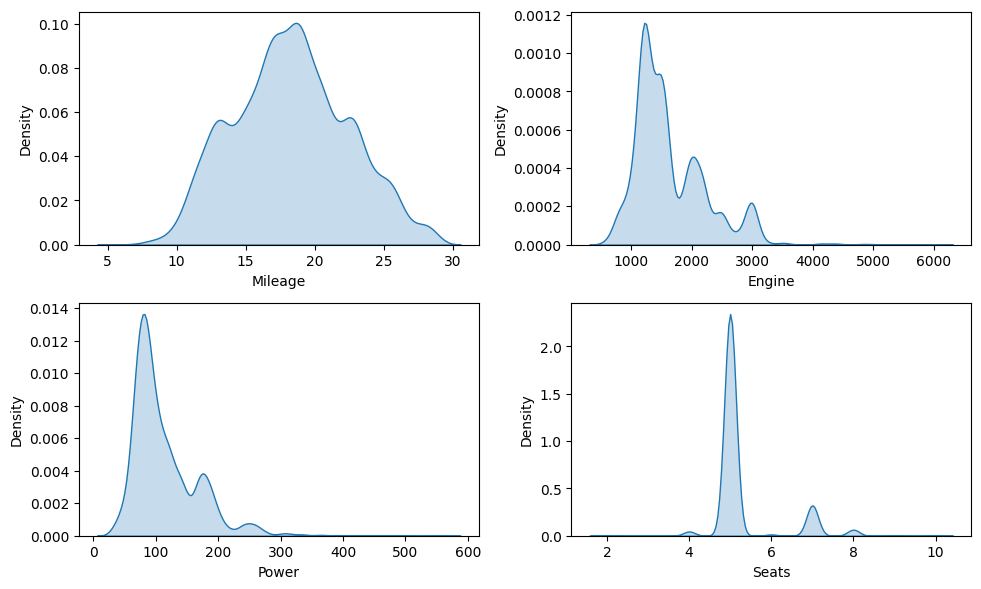

In [274]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
sns.kdeplot(data=car_data, x='Mileage', fill=True, common_norm=False, ax=axes[0,0])
sns.kdeplot(data=car_data, x='Engine', fill=True, common_norm=False, ax=axes[0,1])
sns.kdeplot(data=car_data, x='Power', fill=True, common_norm=False, ax=axes[1,0])
sns.kdeplot(data=car_data, x='Seats', fill=True, common_norm=False, ax=axes[1,1])

plt.tight_layout()
plt.show()

In [275]:
for col in ['Mileage','Engine','Power','Seats']:
  mean = car_data[col].mean()
  median = car_data[col].median()
  print(f'{col} Mean: {mean:.2f}')
  print(f'{col} Median: {median}')

Mileage Mean: 18.29
Mileage Median: 18.2
Engine Mean: 1631.79
Engine Median: 1497.0
Power Mean: 113.82
Power Median: 98.6
Seats Mean: 5.29
Seats Median: 5.0


Most of these columns are right skewed (beside mileage). To avoid affects of outliers, median will be used to replace missing values.

Now that the numeric columns are the right datatype, we can calculate values to impute missing values.

For the rest of the columns with nulls (Engine, Power, Seats), missing values will be replaced based on the median of the observations of the specific car type (make and model) that the missing value belongs to. This is because an observation with missing values will likely have similar specs to other cars of the exact same model. If there are no other cars with the exact same build, then the median of cars from the same make will be used, since they may share things common engine types from that manufacturer. This is still better than taking statistics from the entire dataset.

In [276]:
car_data['Make'] = car_data['Name'].str.split(' ').str[0]
print(car_data['Name'].nunique())
print(car_data['Make'].nunique())

1802
30


In [277]:
# Grouping logic from - https://stackoverflow.com/a/70674157

for col in ['Mileage', 'Engine', 'Power', 'Seats']:
  # Replace by specific model first
  car_data[col] = car_data.groupby(['Name'])[col].transform(lambda x: x.fillna(x.median()))

  # Remaining nulls get replaced by the median of the make
  car_data[col] = car_data.groupby(['Make'])[col].transform(lambda x: x.fillna(x.median()))

  # If no other common makes, use the median of the entire dataset
  car_data[col] = car_data[col].fillna(car_data[col].median())

In [278]:
print(car_data.isna().sum())

car_data.head(15)

Unnamed: 0           0
Name                 0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
Price                0
Make                 0
dtype: int64


,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Make
0,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50,Hyundai
1,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,4.50,Honda
2,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00,Maruti
3,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74,Audi
4,6,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08,1461.0,63.10,5.0,3.50,Nissan
5,7,Toyota Innova Crysta 2.8 GX AT 8S,Mumbai,2016,36000,Diesel,Automatic,First,11.36,2755.0,171.50,8.0,17.50,Toyota
6,8,Volkswagen Vento Diesel Comfortline,Pune,2013,64430,Diesel,Manual,First,20.54,1598.0,103.60,5.0,5.20,Volkswagen
7,9,Tata Indica Vista Quadrajet LS,Chennai,2012,65932,Diesel,Manual,Second,22.30,1248.0,74.00,5.0,1.95,Tata
8,10,Maruti Ciaz Zeta,Kochi,2018,25692,Petrol,Manual,First,21.56,1462.0,103.25,5.0,9.95,Maruti
9,11,Honda City 1.5 V AT Sunroof,Kolkata,2012,60000,Petrol,Automatic,First,16.80,1497.0,116.30,5.0,4.49,Honda


# **Part C) One Hot Encoding**

One Hot Encode both the Fuel_Type and Transmission columns
* The original columns should be dropped after

In [279]:
# One Hot Encode Fuel_Type
car_data = pd.concat([car_data, pd.get_dummies(car_data['Fuel_Type'], prefix='Fuel_Type', dtype=np.int8)], axis=1)
car_data.drop(columns=['Fuel_Type'], inplace=True)

# One Hot Encode Transmission
car_data = pd.concat([car_data, pd.get_dummies(car_data['Transmission'], prefix='Transmission', dtype=np.int8)], axis=1)
car_data.drop(columns=['Transmission'], inplace=True)

car_data

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Owner_Type,Mileage,Engine,Power,Seats,Price,Make,Fuel_Type_Diesel,Fuel_Type_Petrol,Transmission_Automatic,Transmission_Manual
0,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,First,19.67,1582.0,126.20,5.0,12.50,Hyundai,1,0,0,1
1,2,Honda Jazz V,Chennai,2011,46000,First,18.20,1199.0,88.70,5.0,4.50,Honda,0,1,0,1
2,3,Maruti Ertiga VDI,Chennai,2012,87000,First,20.77,1248.0,88.76,7.0,6.00,Maruti,1,0,0,1
3,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Second,15.20,1968.0,140.80,5.0,17.74,Audi,1,0,1,0
4,6,Nissan Micra Diesel XV,Jaipur,2013,86999,First,23.08,1461.0,63.10,5.0,3.50,Nissan,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5842,6014,Maruti Swift VDI,Delhi,2014,27365,First,28.40,1248.0,74.00,5.0,4.75,Maruti,1,0,0,1
5843,6015,Hyundai Xcent 1.1 CRDi S,Jaipur,2015,100000,First,24.40,1120.0,71.00,5.0,4.00,Hyundai,1,0,0,1
5844,6016,Mahindra Xylo D4 BSIV,Jaipur,2012,55000,Second,14.00,2498.0,112.00,8.0,2.90,Mahindra,1,0,0,1
5845,6017,Maruti Wagon R VXI,Kolkata,2013,46000,First,18.90,998.0,67.10,5.0,2.65,Maruti,0,1,0,1


Since both of the columns only had 2 values each (after getting rid of the electric car samples), I believe binary encoding may have been a more suitable choice in this case.

# **Part D) New Feature**

Add the age of the car to the dataset

In [280]:
car_data['Age'] = date.today().year - car_data['Year']

car_data.head(5).T

,0,1,2,3,4
Unnamed: 0,1,2,3,4,6
Name,Hyundai Creta 1.6 CRDi SX Option,Honda Jazz V,Maruti Ertiga VDI,Audi A4 New 2.0 TDI Multitronic,Nissan Micra Diesel XV
Location,Pune,Chennai,Chennai,Coimbatore,Jaipur
Year,2015,2011,2012,2013,2013
Kilometers_Driven,41000,46000,87000,40670,86999
Owner_Type,First,First,First,Second,First
Mileage,19.67,18.2,20.77,15.2,23.08
Engine,1582.0,1199.0,1248.0,1968.0,1461.0
Power,126.2,88.7,88.76,140.8,63.1
Seats,5.0,5.0,7.0,5.0,5.0


Compute how many kilometers were driven per year for each car and add this data to the dataset

In [281]:
car_data['KM_Per_Year'] = (car_data['Kilometers_Driven'] / car_data['Age']).round(2)

car_data.head(5).T

,0,1,2,3,4
Unnamed: 0,1,2,3,4,6
Name,Hyundai Creta 1.6 CRDi SX Option,Honda Jazz V,Maruti Ertiga VDI,Audi A4 New 2.0 TDI Multitronic,Nissan Micra Diesel XV
Location,Pune,Chennai,Chennai,Coimbatore,Jaipur
Year,2015,2011,2012,2013,2013
Kilometers_Driven,41000,46000,87000,40670,86999
Owner_Type,First,First,First,Second,First
Mileage,19.67,18.2,20.77,15.2,23.08
Engine,1582.0,1199.0,1248.0,1968.0,1461.0
Power,126.2,88.7,88.76,140.8,63.1
Seats,5.0,5.0,7.0,5.0,5.0


Save the processed data to a new file

In [282]:
car_data.to_csv(project_path + '/data_clean/clean_car_data.csv')

# **Data Analysis**

# **Part E) Wrangling Operations**

Python equivalents found from:
https://pandas.pydata.org/docs/getting_started/comparison/comparison_with_r.html

Load the clean dataset to use in Part E
* The Mutate and Rename in this section aren't meaningful changes so they don't need to be saved (I am just converting Mileage to different units)




In [294]:
clean_car_data = pd.read_csv(project_path + '/data_clean/clean_car_data.csv')

**Select** only the name and price of the cars

In [295]:
clean_car_data[['Name', 'Price']]

,Name,Price
0,Hyundai Creta 1.6 CRDi SX Option,12.50
1,Honda Jazz V,4.50
2,Maruti Ertiga VDI,6.00
3,Audi A4 New 2.0 TDI Multitronic,17.74
4,Nissan Micra Diesel XV,3.50
...,...,...
5840,Maruti Swift VDI,4.75
5841,Hyundai Xcent 1.1 CRDi S,4.00
5842,Mahindra Xylo D4 BSIV,2.90
5843,Maruti Wagon R VXI,2.65


**Filter** observations where the Kilometers_Driven is less than 50,000 km and the price is less than 10 lakhs

In [296]:
clean_car_data.query('Kilometers_Driven < 50000 & Price < 10')

,Unnamed: 0.1,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Owner_Type,Mileage,Engine,Power,Seats,Price,Make,Fuel_Type_Diesel,Fuel_Type_Petrol,Transmission_Automatic,Transmission_Manual,Age,KM_Per_Year
1,1,2,Honda Jazz V,Chennai,2011,46000,First,18.20,1199.0,88.70,5.0,4.50,Honda,0,1,0,1,15,3066.67
8,8,10,Maruti Ciaz Zeta,Kochi,2018,25692,First,21.56,1462.0,103.25,5.0,9.95,Maruti,0,1,0,1,8,3211.50
15,15,17,Maruti Swift DDiS VDI,Jaipur,2017,25000,First,28.40,1248.0,74.00,5.0,5.99,Maruti,1,0,0,1,9,2777.78
21,21,23,Hyundai i20 1.2 Magna,Kolkata,2010,45807,First,18.50,1197.0,80.00,5.0,1.87,Hyundai,0,1,0,1,16,2862.94
22,22,24,Volkswagen Vento Petrol Highline AT,Kolkata,2010,33000,First,14.40,1598.0,103.60,5.0,2.85,Volkswagen,0,1,1,0,16,2062.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5836,5838,6010,Honda Brio 1.2 VX MT,Delhi,2013,33746,First,18.50,1198.0,86.80,5.0,3.20,Honda,0,1,0,1,13,2595.85
5838,5840,6012,Toyota Innova 2.5 V Diesel 7-seater,Coimbatore,2011,45004,First,12.80,2494.0,102.00,7.0,9.48,Toyota,1,0,0,1,15,3000.27
5840,5842,6014,Maruti Swift VDI,Delhi,2014,27365,First,28.40,1248.0,74.00,5.0,4.75,Maruti,1,0,0,1,12,2280.42
5843,5845,6017,Maruti Wagon R VXI,Kolkata,2013,46000,First,18.90,998.0,67.10,5.0,2.65,Maruti,0,1,0,1,13,3538.46


**Mutate** the Mileage column to be in km/kg instead of kmpl

In [297]:
clean_car_data = clean_car_data.assign(Mileage = (car_data['Mileage'] / 1.4).round(2))

In [298]:
car_data.head()

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Owner_Type,Mileage,Engine,Power,Seats,Price,Make,Fuel_Type_Diesel,Fuel_Type_Petrol,Transmission_Automatic,Transmission_Manual,Age,KM_Per_Year
0,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,First,19.67,1582.0,126.20,5.0,12.50,Hyundai,1,0,0,1,11,3727.27
1,2,Honda Jazz V,Chennai,2011,46000,First,18.20,1199.0,88.70,5.0,4.50,Honda,0,1,0,1,15,3066.67
2,3,Maruti Ertiga VDI,Chennai,2012,87000,First,20.77,1248.0,88.76,7.0,6.00,Maruti,1,0,0,1,14,6214.29
3,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Second,15.20,1968.0,140.80,5.0,17.74,Audi,1,0,1,0,13,3128.46
4,6,Nissan Micra Diesel XV,Jaipur,2013,86999,First,23.08,1461.0,63.10,5.0,3.50,Nissan,1,0,0,1,13,6692.23


**Rename** the Mileage column to indicate the new units (km/kg)

In [299]:
clean_car_data.rename(columns={'Mileage':'Mileage_kg/km'}, inplace=True)

In [300]:
clean_car_data.head()

,Unnamed: 0.1,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Owner_Type,Mileage_kg/km,Engine,Power,Seats,Price,Make,Fuel_Type_Diesel,Fuel_Type_Petrol,Transmission_Automatic,Transmission_Manual,Age,KM_Per_Year
0,0,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,First,14.05,1582.0,126.20,5.0,12.50,Hyundai,1,0,0,1,11,3727.27
1,1,2,Honda Jazz V,Chennai,2011,46000,First,13.00,1199.0,88.70,5.0,4.50,Honda,0,1,0,1,15,3066.67
2,2,3,Maruti Ertiga VDI,Chennai,2012,87000,First,14.84,1248.0,88.76,7.0,6.00,Maruti,1,0,0,1,14,6214.29
3,3,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Second,10.86,1968.0,140.80,5.0,17.74,Audi,1,0,1,0,13,3128.46
4,4,6,Nissan Micra Diesel XV,Jaipur,2013,86999,First,16.49,1461.0,63.10,5.0,3.50,Nissan,1,0,0,1,13,6692.23


**Arrange** the dataframe by number of seats (descending) and then by price (ascending)

In [301]:
clean_car_data.sort_values(by=['Seats', 'Price'], ascending=[False, True]).head(15)

,Unnamed: 0.1,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Owner_Type,Mileage_kg/km,Engine,Power,Seats,Price,Make,Fuel_Type_Diesel,Fuel_Type_Petrol,Transmission_Automatic,Transmission_Manual,Age,KM_Per_Year
788,788,814,Toyota Qualis FS B2,Pune,2004,77757,Second,9.36,2446.0,75.0,10.0,3.50,Toyota,1,0,0,1,22,3534.41
1852,1852,1907,Toyota Qualis FS B3,Bangalore,2002,63000,Third,9.36,2446.0,75.0,10.0,3.65,Toyota,1,0,0,1,24,2625.00
887,887,917,Tata Sumo DX,Mumbai,2013,20000,First,10.05,1978.0,83.1,10.0,5.25,Tata,1,0,0,1,13,1538.46
2492,2492,2575,Chevrolet Tavera LS B3 10 Seats BSIII,Hyderabad,2015,120000,First,10.57,2499.0,80.0,10.0,5.50,Chevrolet,1,0,0,1,11,10909.09
1302,1302,1347,Mahindra Scorpio LX BS IV,Bangalore,2007,74112,First,8.61,2179.0,120.0,9.0,4.10,Mahindra,1,0,0,1,19,3900.63
2289,2289,2359,Mahindra Xylo D2 Maxx,Chennai,2016,150000,First,10.68,2489.0,93.7,9.0,4.50,Mahindra,1,0,0,1,10,15000.00
2244,2244,2312,Chevrolet Tavera LT 9 Str BS IV,Kolkata,2012,67132,First,9.70,2499.0,78.0,9.0,4.75,Chevrolet,1,0,0,1,14,4795.14
4666,4667,4806,Maruti Omni 8 Seater BSII,Jaipur,2004,66624,Third,10.79,796.0,35.0,8.0,0.85,Maruti,0,1,0,1,22,3028.36
4893,4895,5040,Maruti Versa DX2 BS II,Mumbai,2003,62000,Second,9.15,1298.0,83.1,8.0,1.25,Maruti,0,1,0,1,23,2695.65
581,581,602,Maruti Omni 8 Seater BSII,Pune,2010,60000,First,14.07,796.0,35.0,8.0,1.45,Maruti,0,1,0,1,16,3750.00


**Group by** owner type and **summarize** the Kilometers_Driven, Mileage, and Price columns

In [302]:
clean_car_data.groupby('Owner_Type').agg(
    {
        'Kilometers_Driven':['mean', 'median', 'std'],
        'Mileage_kg/km':['mean', 'median', 'std'],
        'Price':['mean', 'median', 'std'],
    }).round(3).reindex(['First', 'Second', 'Third', 'Fourth & Above'])

Kilometers_Driven                      Mileage_kg/km         \
                            mean   median         std          mean median   
Owner_Type                                                                   
First                  55196.710  50000.0  100103.381        13.211  13.29   
Second                 71175.587  66000.0   35493.938        12.362  12.15   
Third                  88901.252  81000.0   40727.041        11.784  11.86   
Fourth & Above        124354.125  85000.0   80965.072         9.901   9.50   

                        Price                 
                  std    mean median     std  
Owner_Type                                    
First           2.916  10.104  5.990  11.490  
Second          2.887   7.840  4.500   9.658  
Third           2.631   5.348  2.950  12.577  
Fourth & Above  2.067   3.415  3.125   1.339